In [1]:
import sympy as sp
from sympy import latex

Very important we are generating only solution for idir=x

This should no work. And all the typos should have been corrected. Derivative can be build. But it is very ugly

In [2]:
D_L, w_L, gamma_L, vx_L, vy_L, vz_L,b0_L, bx_L, by_L, bz_L, p_L, Bx_L, By_L, Bz_L = sp.symbols('D^L w^L gamma^L v_x^L v_y^L v_z^L b0^L b_x^L b_y^L b_z^L p_L B_x^L B_y^L B_z^L', real=True)
D_R, w_R, gamma_R, vx_R, vy_R, vz_R,b0_R, bx_R, by_R, bz_R, p_R, Bx_R, By_R, Bz_R = sp.symbols('D^R w^R gamma^R v_x^R v_y^R v_z^R b0^R b_x^R b_y^R b_z^R p_R B_x^R B_y^R B_z^R', real=True)

p = sp.symbols('p', positive=True, real=True)
la_L, la_R, la_aL, la_c, la_aR = sp.symbols('\\lambda^L \\lambda^R \\lambda^{aL} \\lambda^c \\lambda^{aR}', real=True)


# w_L = rho_L * h_L. But we evolve w so we never have to calculate it again.
# h_L = 1 + epsilon_L + p_L/rho_L
# h = (e+p)/rho = 1 + epsilon + p/rho
# p_L = p_total - 0.5*b2_L

U_L = sp.Matrix([D_L, w_L*gamma_L**2*vx_L-b0_L*bx_L, w_L*gamma_L**2*vy_L-b0_L*by_L, w_L*gamma_L**2*vz_L-b0_L*bz_L, w_L * gamma_L**2 - p - b0_L**2, Bx_L, By_L, Bz_L])
U_R = sp.Matrix([D_R, w_R*gamma_R**2*vx_R-b0_R*bx_R, w_R*gamma_R**2*vy_R-b0_R*by_R, w_R*gamma_R**2*vz_R-b0_R*bz_R, w_R * gamma_R**2 - p - b0_R**2, Bx_R, By_R, Bz_R])

F_L = sp.Matrix([D_L*vx_L, w_L*gamma_L**2*vx_L*vx_L - bx_L*bx_L + p, w_L*gamma_L**2*vx_L*vy_L - bx_L*by_L, w_L*gamma_L**2*vx_L*vz_L - bx_L*bz_L, w_L*gamma_L**2*vx_L - b0_L*bx_L, 0, By_L*vx_L - vy_L*Bx_L, Bz_L*vx_L - vz_L*Bx_L])
F_R = sp.Matrix([D_R*vx_R, w_R*gamma_R**2*vx_R*vx_R - bx_R*bx_R + p, w_R*gamma_R**2*vx_R*vy_R - bx_R*by_R, w_R*gamma_R**2*vx_R*vz_R - bx_R*bz_R, w_R*gamma_R**2*vx_R - b0_R*bx_R, 0, By_R*vx_R - vy_R*Bx_R, Bz_R*vx_R - vz_R*Bx_R])

D = 0
Sx = 1
Sy = 2
Sz = 3
tau = 4
Bx = 5
By = 6
Bz = 7

R_L = la_L * U_L - F_L
R_R = la_R * U_R - F_R

A_L = R_L[Sx] - la_L * R_L[tau] + p*(1-la_L**2)
A_R = R_R[Sx] - la_R * R_R[tau] + p*(1-la_R**2)

G_L = R_L[By]*R_L[By] + R_L[Bz]*R_L[Bz]
G_R = R_R[By]*R_R[By] + R_R[Bz]*R_R[Bz]

C_L = R_L[Sy]*R_L[Bz]
C_R = R_R[Sy]*R_R[Bz]

Q_L = - A_L - G_L + Bx_L**2*(1-la_L**2)
Q_R = - A_R - G_R + Bx_R**2*(1-la_R**2)

X_L = Bx_L * (A_L * la_L * Bx_L + C_L) - (A_L + G_L)*(la_L*p + R_L[tau])
X_R = Bx_R * (A_R * la_R * Bx_R + C_R) - (A_R + G_R)*(la_R*p + R_R[tau])

vx_aL = (Bx_L * (A_L * Bx_L + la_L*C_L) - (A_L + G_L) * (p + R_L[Sx])) / X_L
vx_aR = (Bx_R * (A_R * Bx_R + la_R*C_R) - (A_R + G_R) * (p + R_R[Sx])) / X_R

vy_aL = (Q_L * R_L[Sy] + R_L[By] * (C_L + Bx_L * (la_L*R_L[Sx] - R_L[tau]))) / X_L
vy_aR = (Q_R * R_R[Sy] + R_R[By] * (C_R + Bx_R * (la_R*R_R[Sx] - R_R[tau]))) / X_R

vz_aL = (Q_L * R_L[Sz] + R_L[Bz] * (C_L + Bx_L * (la_L*R_L[Sx] - R_L[tau]))) / X_L
vz_aR = (Q_R * R_R[Sz] + R_R[Bz] * (C_R + Bx_R * (la_R*R_R[Sx] - R_R[tau]))) / X_R

By_aL = (R_L[By] - Bx_L * vy_aL) / (la_L - vx_aL)
By_aR = (R_R[By] - Bx_R * vy_aR) / (la_R - vx_aR)

Bz_aL = (R_L[Bz] - Bx_L * vz_aL) / (la_L - vx_aL)
Bz_aR = (R_R[Bz] - Bx_R * vz_aR) / (la_R - vx_aR)

w_aL = p + (R_L[tau] - R_L[Sx]*vx_aL - R_L[Sy]*vy_aL - R_L[Sz]*vz_aL) / (la_L - vx_aL)
w_aR = p + (R_R[tau] - R_R[Sx]*vx_aR - R_R[Sy]*vy_aR - R_R[Sz]*vz_aR) / (la_R - vx_aR)

D_aL = R_L[D] / (la_L - vx_aL)
D_aR = R_R[D] / (la_R - vx_aR)

tau_aL = (R_L[tau] + p*vx_aL - (vx_aL*Bx_L + vy_aL*By_aL + vz_aL*Bz_aL)*Bx_L) / (la_L - vx_aL)
tau_aR = (R_R[tau] + p*vx_aR - (vx_aR*Bx_R + vy_aR*By_aR + vz_aR*Bz_aR)*Bx_R) / (la_R - vx_aR)

Sx_aL = (tau_aL + p) * vx_aL - (vx_aL*Bx_L + vy_aL*By_aL + vz_aL*Bz_aL)*Bx_L
Sx_aR = (tau_aR + p) * vx_aR - (vx_aR*Bx_R + vy_aR*By_aR + vz_aR*Bz_aR)*Bx_R
Sy_aL = (tau_aL + p) * vy_aL - (vx_aL*Bx_L + vy_aL*By_aL + vz_aL*Bz_aL)*By_aL
Sy_aR = (tau_aR + p) * vy_aR - (vx_aR*Bx_R + vy_aR*By_aR + vz_aR*Bz_aR)*By_aR
Sz_aL = (tau_aL + p) * vz_aL - (vx_aL*Bx_L + vy_aL*By_aL + vz_aL*Bz_aL)*Bz_aL
Sz_aR = (tau_aR + p) * vz_aR - (vx_aR*Bx_R + vy_aR*By_aR + vz_aR*Bz_aR)*Bz_aR


Kx_aL = ((R_L[Sx] + p - R_L[Bx]*sp.sign(Bx_L)*sp.sqrt(w_aL))/(la_L*p + R_L[tau] - Bx_L*sp.sign(Bx_L) * sp.sqrt(w_aL)))
Kx_aR = ((R_R[Sx] + p + R_R[Bx]*sp.sign(Bx_R)*sp.sqrt(w_aR))/(la_R*p + R_R[tau] + Bx_R*sp.sign(Bx_R) * sp.sqrt(w_aR)))

Ky_aL = ((R_L[Sy] - R_L[By] * sp.sign(Bx_L)*sp.sqrt(w_aL))/(la_L*p + R_L[tau] - Bx_L*sp.sign(Bx_L) * sp.sqrt(w_aL)))
Ky_aR = ((R_R[Sy] + R_R[By] * sp.sign(Bx_R)*sp.sqrt(w_aR))/(la_R*p + R_R[tau] + Bx_R*sp.sign(Bx_R) * sp.sqrt(w_aR)))

Kz_aL = ((R_L[Sz] - R_L[Bz] * sp.sign(Bx_L)*sp.sqrt(w_aL))/(la_L*p + R_L[tau] - Bx_L*sp.sign(Bx_L) * sp.sqrt(w_aL)))
Kz_aR = ((R_R[Sz] + R_R[Bz] * sp.sign(Bx_R)*sp.sqrt(w_aR))/(la_R*p + R_R[tau] + Bx_R*sp.sign(Bx_R) * sp.sqrt(w_aR)))

# This is from Kiuchi paper
Kx_L = vx_L + Bx_L / (gamma_L**2 * (sp.sign(Bx_L) * sp.sqrt(w_L) + vx_L*Bx_L + vy_L*By_L + vz_L*Bz_L))
Kx_R = vx_R + Bx_R / (gamma_R**2 * (sp.sign(Bx_R) * sp.sqrt(w_R) + vx_R*Bx_R + vy_R*By_R + vz_R*Bz_R))

Ky_L = vy_L + By_L / (gamma_L**2 * (sp.sign(Bx_L) * sp.sqrt(w_L) + vx_L*Bx_L + vy_L*By_L + vz_L*Bz_L))
Ky_R = vy_R + By_R / (gamma_R**2 * (sp.sign(Bx_R) * sp.sqrt(w_R) + vx_R*Bx_R + vy_R*By_R + vz_R*Bz_R))      

Kz_L = vz_L + Bz_L / (gamma_L**2 * (sp.sign(Bx_L) * sp.sqrt(w_L) + vx_L*Bx_L + vy_L*By_L + vz_L*Bz_L))
Kz_R = vz_R + Bz_R / (gamma_R**2 * (sp.sign(Bx_R) * sp.sqrt(w_R) + vx_R*Bx_R + vy_R*By_R + vz_R*Bz_R))  

la_aL = Kx_aL
la_aR = Kx_aR

K2_L = Kx_aL**2 + Ky_aL**2 + Kz_aL**2
K2_R = Kx_aR**2 + Ky_aR**2 + Kz_aR**2

Bcx = (Bx_R * (la_aR - vx_aR) + Bx_R * vx_aR) / (la_aR - la_aL) - (Bx_L * (la_aL - vx_aL) + Bx_L * vx_aL) / (la_aR - la_aL)
Bcy = (By_R * (la_aR - vx_aR) + Bx_R * vy_aR) / (la_aR - la_aL) - (By_L * (la_aL - vx_aL) + Bx_L * vy_aL) / (la_aR - la_aL)
Bcz = (Bz_R * (la_aR - vx_aR) + Bx_R * vz_aR) / (la_aR - la_aL) - (Bz_L * (la_aL - vx_aL) + Bx_L * vz_aL) / (la_aR - la_aL)

Bc_K_L = Bcx * Kx_aL + Bcy * Ky_aL + Bcz * Kz_aL
Bc_K_R = Bcx * Kx_aR + Bcy * Ky_aR + Bcz * Kz_aR


function = (Kx_aL - Kx_aR) + Bx_L * ((1-K2_R)/(sp.sign(Bx_R) * sp.sqrt(w_R) - Bc_K_R) + (1-K2_L)/(sp.sign(Bx_L) * sp.sqrt(w_L) + Bc_K_L))


In [3]:
df_dp_full = sp.diff(function, p)

In [4]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("../data/raw/dataset_mignone.npz")
print(list(d.keys()))          # what fields were saved
#print(d['p_star'].shape)       # or whatever your key is

# Check for NaNs / Infs
for k in d.keys():
    arr = d[k]
    print(f"{k:15s}  shape={arr.shape}  min={arr.min():.3e}  max={arr.max():.3e}  "
          f"nan={np.isnan(arr).sum()}  inf={np.isinf(arr).sum()}")

['inputs', 'targets']
inputs           shape=(1000000, 15)  min=-2.000e+00  max=1.994e+02  nan=0  inf=0
targets          shape=(1000000,)  min=-2.510e+05  max=3.199e+05  nan=0  inf=0


NpzFile '../data/raw/dataset_mignone.npz' with keys: inputs, targets
771508


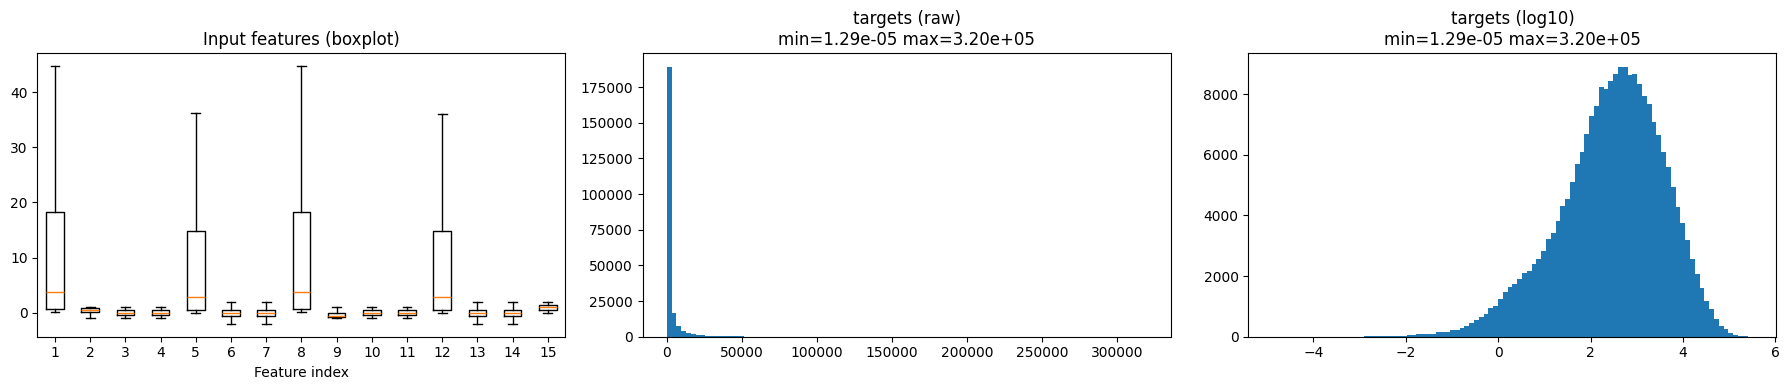

In [12]:
import numpy as np
import matplotlib.pyplot as plt

d = np.load("../data/raw/dataset_mignone.npz")
#d = np.load("../data/splits/default-mignone/test.npz")
print(d)
inputs  = d['inputs']   # (100000, 15)
targets = d['targets']  # (100000,)

mask = targets > 0.0000001
inputs  = inputs[mask]
targets = targets[mask]

print(len(mask)-len(inputs))

#mask = targets < 100000
#inputs  = inputs[mask]
#targets = targets[mask]

log_targets = np.log10(targets)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Input distributions (all 15 features)
axes[0].boxplot(inputs, showfliers=False)
axes[0].set_title("Input features (boxplot)")
axes[0].set_xlabel("Feature index")

# Target distribution — raw
axes[1].hist(targets, bins=100)
axes[1].set_title(f"targets (raw)\nmin={targets.min():.2e} max={targets.max():.2e}")

# Target distribution — log10
axes[2].hist(log_targets, bins=100)
axes[2].set_title(f"targets (log10)\nmin={targets.min():.2e} max={targets.max():.2e}")

plt.tight_layout()
plt.savefig("../data/raw/distributions_mignone.png")
plt.show()

In [6]:
idx = np.argsort(targets)[-5:][::-1]   # indices of 5 largest, descending

labels = ["rho_L","vx_L","vy_L","vz_L","p_L","By_L","Bz_L",
          "rho_R","vx_R","vy_R","vz_R","p_R","By_R","Bz_R","Bx"]

for rank, i in enumerate(idx):
    print(f"\n--- Rank {rank+1}  (p_star={targets[i]:.4e}) ---")
    for name, val in zip(labels, inputs[i]):
        print(f"  {name:6s} = {val:.4e}")


--- Rank 1  (p_star=2.5465e+00) ---
  rho_L  = 3.4368e+00
  vx_L   = 5.0613e-01
  vy_L   = 1.3448e+00
  vz_L   = -5.5330e-01
  p_L    = 3.7858e+00
  By_L   = 6.8208e-01
  Bz_L   = 1.2664e+00
  rho_R  = 2.4763e+00
  vx_R   = -1.0783e+00
  vy_R   = -6.7861e-01
  vz_R   = 5.8899e-02
  p_R    = 2.5281e+00
  By_R   = -1.6010e+00
  Bz_R   = 2.8428e-01
  Bx     = -1.5151e+00

--- Rank 2  (p_star=2.4957e+00) ---
  rho_L  = 3.0144e+00
  vx_L   = 8.8612e-01
  vy_L   = -8.0671e-01
  vz_L   = 6.4854e-01
  p_L    = 5.0213e+00
  By_L   = -6.8294e-01
  Bz_L   = -1.7865e+00
  rho_R  = 1.6295e+00
  vx_R   = -1.0376e+00
  vy_R   = -6.8550e-01
  vz_R   = 3.6121e-01
  p_R    = 3.6913e-01
  By_R   = 1.2663e+00
  Bz_R   = -6.7225e-02
  Bx     = -1.6706e+00

--- Rank 3  (p_star=2.4238e+00) ---
  rho_L  = 2.1239e+00
  vx_L   = 1.1621e+00
  vy_L   = 4.3261e-01
  vz_L   = -1.8010e-03
  p_L    = 2.8096e-01
  By_L   = 6.7346e-01
  Bz_L   = 1.5144e-01
  rho_R  = 3.4901e+00
  vx_R   = -6.5811e-01
  vy_R   = 5.1801

In [7]:
rho, h, c2 , a, la, B2, b2, vx = sp.symbols('rho h c^2 a \\lambda B^2 b^2 vx', real=True)
func = rho * h * (1 - c2) * a**4 - (1-la**2) * ((b2 + rho * h * c2) * a**2 - c2 * B2)
func

a**4*h*rho*(1 - c^2) - (1 - \lambda**2)*(-B^2*c^2 + a**2*(b^2 + c^2*h*rho))

In [8]:
func_sub = func.subs(a, la - vx)
func_sub = sp.expand(func_sub)